In [1]:
import sys
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from datetime import datetime

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

print("=" * 70)
print("ЗАПУСК ПОЛНОГО ПАЙПЛАЙНА ДЛЯ FMA MEDIUM")
print("=" * 70)
print(f"Время начала: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Корень проекта: {PROJECT_ROOT}")
print("=" * 70)

ЗАПУСК ПОЛНОГО ПАЙПЛАЙНА ДЛЯ FMA MEDIUM
Время начала: 2026-05-07 10:54:36
Корень проекта: D:\Projects\PythonProject\music-genre-classification-fma


In [2]:
from src.utils.config import paths, audio_params

print("\n📁 ПРОВЕРКА КОНФИГУРАЦИИ")
print("-" * 50)
print(f"Активный датасет: {paths.active_subset}")
print(f"ZIP архив: {paths.active_zip}")
print(f"ZIP существует: {paths.active_zip.exists()}")

print(f"\nМетаданные:")
print(f"  tracks.csv: {paths.get_tracks_csv().exists()}")
print(f"  features.csv: {paths.get_features_csv().exists()}")
print(f"  genres.csv: {paths.get_genres_csv().exists()}")

print(f"\nАудио параметры:")
print(f"  sample_rate: {audio_params.sample_rate}")
print(f"  duration: {audio_params.duration} сек")
print(f"  n_mfcc: {audio_params.n_mfcc}")

paths.ensure_dirs()
print(f"\n✅ Директории созданы")


📁 ПРОВЕРКА КОНФИГУРАЦИИ
--------------------------------------------------
Активный датасет: medium
ZIP архив: E:\music-genre-classifier\fma_medium.zip
ZIP существует: True

Метаданные:
  tracks.csv: True
  features.csv: True
  genres.csv: True

Аудио параметры:
  sample_rate: 22050
  duration: 30 сек
  n_mfcc: 20

✅ Директории созданы


In [3]:
from src.data.pipeline import DataPipeline

print("\n" + "=" * 70)
print("ЗАПУСК DATA PIPELINE")
print("=" * 70)
print("Параметры:")
print(f"  subset: medium")
print(f"  min_samples_per_genre: 10")
print(f"  use_features: True")
print(f"  check_audio_availability: True")
print("-" * 50)

pipeline = DataPipeline(
    subset="medium",
    min_samples_per_genre=10,
    use_features=True,
    check_audio_availability=True
)

print("\n⏳ Запуск обработки данных (может занять 2-5 минут)...\n")
data = pipeline.run(force_reload=True)

print("\n✅ Пайплайн успешно завершён!")


ЗАПУСК DATA PIPELINE
Параметры:
  subset: medium
  min_samples_per_genre: 10
  use_features: True
  check_audio_availability: True
--------------------------------------------------

⏳ Запуск обработки данных (может занять 2-5 минут)...

🚀 ЗАПУСК ПАЙПЛАЙНА ПОДГОТОВКИ ДАННЫХ (FMA MEDIUM)
Загружено tracks: (106574, 52)
Треков в medium: 25000

📊 Шаг 1/9: Загружено треков с жанром: 25000
Осталось жанров: 16
Осталось треков: 25000

📊 Шаг 2/9: Официальное разбиение FMA:
   Train: 19922 (79.7%)
   Val:   2505 (10.0%)
   Test:  2573 (10.3%)
Загружено features: (106574, 518)

📊 Шаг 3/9: Размеры выборок после сопоставления:
   X_train: (19922, 518)
   X_val:   (2505, 518)
   X_test:  (2573, 518)
Закодировано классов: 16
  0: Blues
  1: Classical
  2: Country
  3: Easy Listening
  4: Electronic
  5: Experimental
  6: Folk
  7: Hip-Hop
  8: Instrumental
  9: International
  10: Jazz
  11: Old-Time / Historic
  12: Pop
  13: Rock
  14: Soul-RnB
  15: Spoken
X_train: mean=0.0000, std=1.0000
X_val: 

In [4]:
print("\n" + "=" * 70)
print("АНАЛИЗ РЕЗУЛЬТАТОВ ПАЙПЛАЙНА")
print("=" * 70)

print(f"\n📊 Форматы данных:")
print(f"  X_train: {data['X_train'].shape}")
print(f"  X_val:   {data['X_val'].shape}")
print(f"  X_test:  {data['X_test'].shape}")
print(f"  y_train: {data['y_train'].shape}")
print(f"  y_val:   {data['y_val'].shape}")
print(f"  y_test:  {data['y_test'].shape}")

print(f"\n🎵 Информация о треках:")
print(f"  train_indices: {len(data['train_indices'])}")
print(f"  val_indices:   {len(data['val_indices'])}")
print(f"  test_indices:  {len(data['test_indices'])}")

print(f"\n🎼 Жанры ({len(data['genre_names'])}):")
for i, genre in enumerate(data['genre_names']):
    print(f"  {i:2d}: {genre}")

print(f"\n📈 Статистика нормализации:")
print(f"  X_train mean: {data['X_train'].mean():.6f}, std: {data['X_train'].std():.6f}")
print(f"  X_val mean:   {data['X_val'].mean():.6f}, std: {data['X_val'].std():.6f}")
print(f"  X_test mean:  {data['X_test'].mean():.6f}, std: {data['X_test'].std():.6f}")

print(f"\n🔍 Проверка на пропуски:")
print(f"  NaN в X_train: {np.isnan(data['X_train']).sum()}")
print(f"  NaN в X_val:   {np.isnan(data['X_val']).sum()}")
print(f"  NaN в X_test:  {np.isnan(data['X_test']).sum()}")


АНАЛИЗ РЕЗУЛЬТАТОВ ПАЙПЛАЙНА

📊 Форматы данных:
  X_train: (19922, 518)
  X_val:   (2505, 518)
  X_test:  (2573, 518)
  y_train: (19922,)
  y_val:   (2505,)
  y_test:  (2573,)

🎵 Информация о треках:
  train_indices: 19922
  val_indices:   2505
  test_indices:  2573

🎼 Жанры (16):
   0: Blues
   1: Classical
   2: Country
   3: Easy Listening
   4: Electronic
   5: Experimental
   6: Folk
   7: Hip-Hop
   8: Instrumental
   9: International
  10: Jazz
  11: Old-Time / Historic
  12: Pop
  13: Rock
  14: Soul-RnB
  15: Spoken

📈 Статистика нормализации:
  X_train mean: 0.000000, std: 1.000000
  X_val mean:   0.006083, std: 1.088028
  X_test mean:  -0.007590, std: 1.010437

🔍 Проверка на пропуски:
  NaN в X_train: 0
  NaN в X_val:   0
  NaN в X_test:  0


In [5]:
print("\n" + "=" * 70)
print("ДОСТУПНОСТЬ АУДИО В ZIP АРХИВЕ")
print("=" * 70)

audio_avail = data.get('audio_availability')
if audio_avail:
    print(f"\n📀 Train:")
    print(f"   Доступно: {audio_avail['train']['available']}/{audio_avail['train']['total']} ({audio_avail['train']['available_rate']:.1%})")
    if audio_avail['train']['missing'] > 0:
        print(f"   Отсутствует: {audio_avail['train']['missing']} треков")
        print(f"   Примеры: {audio_avail['train']['missing_list'][:10]}")

    print(f"\n📀 Val:")
    print(f"   Доступно: {audio_avail['val']['available']}/{audio_avail['val']['total']} ({audio_avail['val']['available_rate']:.1%})")
    if audio_avail['val']['missing'] > 0:
        print(f"   Отсутствует: {audio_avail['val']['missing']} треков")

    print(f"\n📀 Test:")
    print(f"   Доступно: {audio_avail['test']['available']}/{audio_avail['test']['total']} ({audio_avail['test']['available_rate']:.1%})")
    if audio_avail['test']['missing'] > 0:
        print(f"   Отсутствует: {audio_avail['test']['missing']} треков")
else:
    print("⚠️ Информация о доступности аудио не найдена")


ДОСТУПНОСТЬ АУДИО В ZIP АРХИВЕ

📀 Train:
   Доступно: 19922/19922 (100.0%)

📀 Val:
   Доступно: 2505/2505 (100.0%)

📀 Test:
   Доступно: 2573/2573 (100.0%)



АНАЛИЗ РАСПРЕДЕЛЕНИЯ ЖАНРОВ


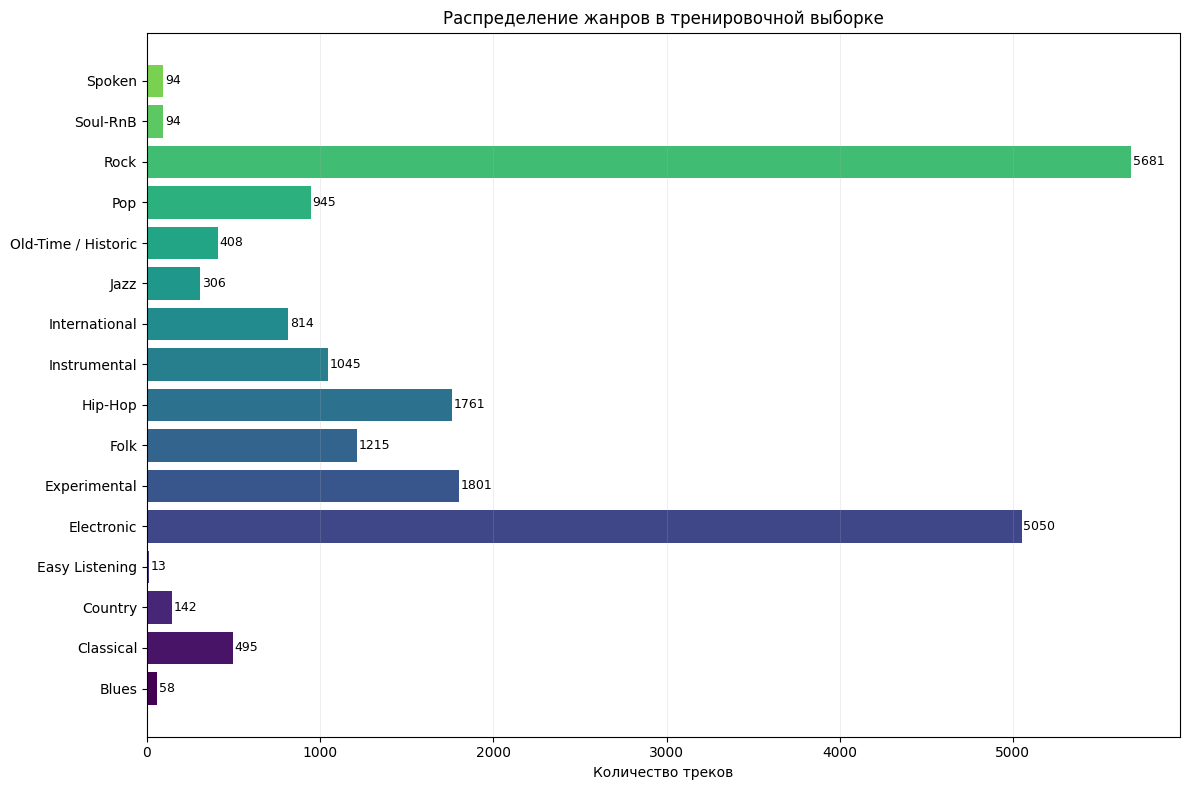


✅ График сохранён: D:\Projects\PythonProject\music-genre-classification-fma\results\genre_distribution_medium.png


In [6]:
import matplotlib.pyplot as plt

print("\n" + "=" * 70)
print("АНАЛИЗ РАСПРЕДЕЛЕНИЯ ЖАНРОВ")
print("=" * 70)

unique, counts = np.unique(data['y_train'], return_counts=True)
genre_counts = dict(zip(unique, counts))

fig, ax = plt.subplots(figsize=(12, 8))
genres = [data['genre_names'][i] for i in unique]
counts_list = [counts[i] for i in range(len(unique))]
colors = plt.cm.viridis(np.linspace(0, 0.8, len(genres)))

bars = ax.barh(genres, counts_list, color=colors)
ax.set_xlabel('Количество треков')
ax.set_title('Распределение жанров в тренировочной выборке')
ax.grid(axis='x', alpha=0.3)

for bar, count in zip(bars, counts_list):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{count}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(paths.results_dir / 'genre_distribution_medium.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ График сохранён: {paths.results_dir / 'genre_distribution_medium.png'}")

In [7]:


print("\n" + "=" * 70)
print("ПРОВЕРКА КЭШИРОВАННЫХ ФАЙЛОВ")
print("=" * 70)

cache_dir = paths.processed_data_dir
print(f"Директория кэша: {cache_dir}")

if cache_dir.exists():
    files = list(cache_dir.glob("*"))
    print(f"\n📁 Найдено файлов: {len(files)}")

    file_types = {}
    for f in files:
        ext = f.suffix if f.suffix else "no_ext"
        if ext not in file_types:
            file_types[ext] = []
        file_types[ext].append(f)

    for ext, flist in sorted(file_types.items()):
        total_size = sum(f.stat().st_size for f in flist) / 1024 / 1024
        print(f"\n  {ext}: {len(flist)} файлов, {total_size:.2f} MB")

    print(f"\n📄 Ключевые файлы:")
    key_files = ['X_train.npy', 'y_train.npy', 'train_indices.npy', 'metadata.json', 'preprocessor.pkl']
    for kf in key_files:
        path = cache_dir / kf
        if path.exists():
            size = path.stat().st_size / 1024 / 1024
            print(f"    ✅ {kf}: {size:.2f} MB")
        else:
            print(f"    ❌ {kf}: не найден")
else:
    print("❌ Директория кэша не найдена")


ПРОВЕРКА КЭШИРОВАННЫХ ФАЙЛОВ
Директория кэша: D:\Projects\PythonProject\music-genre-classification-fma\data\processed

📁 Найдено файлов: 14

  .json: 2 файлов, 0.03 MB

  .npy: 9 файлов, 99.18 MB

  .pkl: 2 файлов, 99.21 MB

  no_ext: 1 файлов, 0.00 MB

📄 Ключевые файлы:
    ✅ X_train.npy: 78.73 MB
    ✅ y_train.npy: 0.15 MB
    ✅ train_indices.npy: 0.15 MB
    ✅ metadata.json: 0.03 MB
    ✅ preprocessor.pkl: 0.01 MB


In [8]:
from src.data.load_processed import load_data

print("\n" + "=" * 70)
print("ТЕСТ БЫСТРОЙ ЗАГРУЗКИ ИЗ КЭША")
print("=" * 70)

import time

start = time.time()
data_reloaded = load_data(subset="medium", min_samples_per_genre=10)
elapsed = time.time() - start

print(f"⏱️ Время загрузки: {elapsed:.2f} сек")
print(f"✅ Данные загружены из кэша")
print(f"   X_train: {data_reloaded['X_train'].shape}")
print(f"   y_train: {data_reloaded['y_train'].shape}")

if np.allclose(data['X_train'], data_reloaded['X_train']):
    print("   ✅ Данные совпадают с оригиналом")
else:
    print("   ⚠️ Данные НЕ совпадают!")


ТЕСТ БЫСТРОЙ ЗАГРУЗКИ ИЗ КЭША
Загрузка данных из D:\Projects\PythonProject\music-genre-classification-fma\data\processed...
✅ Загружены данные: 19922 train, 2505 val, 2573 test
   Жанров: 16
⏱️ Время загрузки: 0.18 сек
✅ Данные загружены из кэша
   X_train: (19922, 518)
   y_train: (19922,)
   ✅ Данные совпадают с оригиналом


In [9]:
from src.data.load_processed import load_track_indices

print("\n" + "=" * 70)
print("ЗАГРУЗКА ИНДЕКСОВ ТРЕКОВ")
print("=" * 70)

train_idx, val_idx, test_idx = load_track_indices(subset="medium", min_samples_per_genre=10)

print(f"Train индексы: {len(train_idx)}")
print(f"Val индексы:   {len(val_idx)}")
print(f"Test индексы:  {len(test_idx)}")

print(f"\nПримеры train индексов: {train_idx[:10].tolist()}")
print(f"Примеры val индексов:   {val_idx[:10].tolist()}")
print(f"Примеры test индексов:  {test_idx[:10].tolist()}")


ЗАГРУЗКА ИНДЕКСОВ ТРЕКОВ
Загрузка данных из D:\Projects\PythonProject\music-genre-classification-fma\data\processed...
✅ Загружены данные: 19922 train, 2505 val, 2573 test
   Жанров: 16
Train индексы: 19922
Val индексы:   2505
Test индексы:  2573

Примеры train индексов: [2, 3, 5, 10, 134, 136, 139, 140, 141, 190]
Примеры val индексов:   [148, 458, 459, 583, 584, 585, 602, 603, 690, 993]
Примеры test индексов:  [181, 182, 564, 704, 705, 706, 707, 708, 709, 734]


In [10]:
from src.data.audio_loader import AudioLoader

print("\n" + "=" * 70)
print("ПРОВЕРКА ДОСТУПНОСТИ АУДИО")
print("=" * 70)

try:
    audio_loader = AudioLoader(use_disk_cache=False)
    available = set(audio_loader.get_available_tracks())
    print(f"✅ Доступно треков в ZIP: {len(available)}")

    test_tracks = train_idx[:5].tolist()
    print(f"\n🔍 Проверка тестовых треков:")
    for track in test_tracks:
        exists = track in available
        status = "✅" if exists else "❌"
        print(f"   {status} Трек {track}")

    audio_loader.close()

except Exception as e:
    print(f"⚠️ Ошибка: {e}")


ПРОВЕРКА ДОСТУПНОСТИ АУДИО
✅ AudioLoader готов: E:\music-genre-classifier\fma_medium.zip
   Размер архива: 22.19 GB
✅ Доступно треков в ZIP: 25000

🔍 Проверка тестовых треков:
   ✅ Трек 2
   ✅ Трек 3
   ✅ Трек 5
   ✅ Трек 10
   ✅ Трек 134


In [11]:
print("\n" + "=" * 70)
print("СОЗДАНИЕ MFCC DATALOADER (ДЛЯ CNN)")
print("=" * 70)

try:
    import torch
    from src.data.torch_dataset import create_mfcc_dataloaders

    print("⏳ Создание DataLoader (может занять время)...")

    train_loader, val_loader, test_loader, genres, failure_report = create_mfcc_dataloaders(
        subset="medium",
        min_samples_per_genre=10,
        batch_size=32,
        target_frames=128,
        use_deltas=True,
        num_workers=0,
        cache_mfcc=True,
        use_disk_cache=True,
        augment_train=False,
        filter_failed_tracks=True
    )

    print(f"\n✅ DataLoader созданы успешно!")
    print(f"   Train батчей: {len(train_loader)}")
    print(f"   Val батчей:   {len(val_loader)}")
    print(f"   Test батчей:  {len(test_loader)}")

    # Проверяем один батч
    for mfcc, labels in train_loader:
        print(f"\n📦 Пример батча:")
        print(f"   MFCC shape: {mfcc.shape}")
        print(f"   Labels: {labels[:5]}...")
        break

except ImportError as e:
    print(f"⚠️ PyTorch не установлен: {e}")
    print("   MFCC DataLoader не будет создан")
except Exception as e:
    print(f"❌ Ошибка: {e}")


СОЗДАНИЕ MFCC DATALOADER (ДЛЯ CNN)
⏳ Создание DataLoader (может занять время)...
Загрузка данных из D:\Projects\PythonProject\music-genre-classification-fma\data\processed...
✅ Загружены данные: 19922 train, 2505 val, 2573 test
   Жанров: 16
Загрузка данных из D:\Projects\PythonProject\music-genre-classification-fma\data\processed...
✅ Загружены данные: 19922 train, 2505 val, 2573 test
   Жанров: 16
СОЗДАНИЕ MFCC DATALOADERS
Датасет: FMA MEDIUM
Train треков: 19922
Val треков:   2505
Test треков:  2573
Жанров: 16
Target frames: 128
Use deltas: True
Аугментация train: False
------------------------------------------------------------
✅ AudioLoader готов: E:\music-genre-classifier\fma_medium.zip
   Размер архива: 22.19 GB
✅ AudioLoader готов: E:\music-genre-classifier\fma_medium.zip
   Размер архива: 22.19 GB
✅ AudioLoader готов: E:\music-genre-classifier\fma_medium.zip
   Размер архива: 22.19 GB

✅ DataLoader созданы:
   Train: 623 батчей по 32
   Val:   79 батчей
   Test:  81 батчей

✅

In [12]:
print("\n" + "=" * 70)
print("ФИНАЛЬНЫЙ ОТЧЁТ ПО ОБРАБОТКЕ FMA MEDIUM")
print("=" * 70)
print(f"Время завершения: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("-" * 50)

# Собираем статистику
stats = {
    "Датасет": "FMA Medium",
    "Треков всего": data['metadata']['num_samples'],
    "Признаков": data['metadata']['num_features'],
    "Жанров": len(data['genre_names']),
    "Train размер": len(data['X_train']),
    "Val размер": len(data['X_val']),
    "Test размер": len(data['X_test']),
    "Треков в ZIP": len(available) if 'available' in dir() else "N/A",
}

print("\n📊 СТАТИСТИКА:")
for key, value in stats.items():
    print(f"   {key:15s}: {value}")

# Проверка доступности
audio_avail = data.get('audio_availability')
if audio_avail:
    print(f"\n🎵 ДОСТУПНОСТЬ АУДИО:")
    print(f"   Train: {audio_avail['train']['available_rate']:.1%}")
    print(f"   Val:   {audio_avail['val']['available_rate']:.1%}")
    print(f"   Test:  {audio_avail['test']['available_rate']:.1%}")

print("\n" + "=" * 70)
print("✅ ОБРАБОТКА FMA MEDIUM УСПЕШНО ЗАВЕРШЕНА!")
print("=" * 70)
print("\n📁 Результаты сохранены в:")
print(f"   {paths.processed_data_dir}")
print(f"\n📊 Для загрузки используйте:")
print(f"   from src.data.load_processed import load_data")
print(f"   data = load_data()")


ФИНАЛЬНЫЙ ОТЧЁТ ПО ОБРАБОТКЕ FMA MEDIUM
Время завершения: 2026-05-07 10:55:35
--------------------------------------------------

📊 СТАТИСТИКА:
   Датасет        : FMA Medium
   Треков всего   : 25000
   Признаков      : 518
   Жанров         : 16
   Train размер   : 19922
   Val размер     : 2505
   Test размер    : 2573
   Треков в ZIP   : 25000

🎵 ДОСТУПНОСТЬ АУДИО:
   Train: 100.0%
   Val:   100.0%
   Test:  100.0%

✅ ОБРАБОТКА FMA MEDIUM УСПЕШНО ЗАВЕРШЕНА!

📁 Результаты сохранены в:
   D:\Projects\PythonProject\music-genre-classification-fma\data\processed

📊 Для загрузки используйте:
   from src.data.load_processed import load_data
   data = load_data()
